# Deep Learning — Week 2: Logistic Regression & Binary Classification

---
# Part 2. 실습 문제 — 정답본

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## [A] 한 줄 채우기 — 정답

In [2]:
# A-1. 시그모이드 함수
def sigmoid(z):
    return 1 / (1 + np.exp(-z))   # ← 정답

print('sigmoid(-2):', sigmoid(-2))   # ≈ 0.119
print('sigmoid( 0):', sigmoid(0))    # = 0.5
print('sigmoid( 2):', sigmoid(2))    # ≈ 0.881

sigmoid(-2): 0.11920292202211755
sigmoid( 0): 0.5
sigmoid( 2): 0.8807970779778823


In [3]:
# A-2. 시그모이드 미분
def sigmoid_grad(z):
    s = sigmoid(z)
    return s * (1 - s)   # ← 정답

print('sigmoid_grad(0):', sigmoid_grad(0))    # = 0.25
print('sigmoid_grad(5):', sigmoid_grad(5))    # ≈ 0.007

# 강사 노트: sigmoid_grad(5) ≈ 0.007 이 매우 작은 것을 주목
# → z값이 커질수록 gradient가 거의 0에 가까워짐
# → 깊은 신경망에서 역전파 시 gradient가 소멸 = Vanishing Gradient
# → 생각해볼 질문 1번의 핵심

sigmoid_grad(0): 0.25
sigmoid_grad(5): 0.006648056670790033


In [4]:
# A-3. Forward pass
np.random.seed(0)
X_test = np.random.randn(5, 3)
w_test = np.random.randn(3, 1)
b_test = 0.0

y_pred_test = sigmoid(X_test @ w_test + b_test)   # ← 정답
print('y_pred shape:', y_pred_test.shape)   # (5, 1)
print('y_pred:\n', y_pred_test)

y_pred shape: (5, 1)
y_pred:
 [[0.72823564]
 [0.97676314]
 [0.52798489]
 [0.51346235]
 [0.58532414]]


In [5]:
# A-4. BCE Loss 계산
y_true_test = np.array([[1], [0], [1], [1], [0]])
y_pred_bce  = np.array([[0.5], [0.5], [0.5], [0.5], [0.5]])
eps = 1e-8

# ← 정답
loss_test = -np.mean(y_true_test * np.log(y_pred_bce + eps) +
                     (1 - y_true_test) * np.log(1 - y_pred_bce + eps))
print('BCE Loss (random prediction):', loss_test)   # ≈ 0.693

# 강사 노트: 0.693 = log(2) — 아무것도 모를 때(0.5) loss의 기댓값
# 학습이 잘 되면 이 값보다 낮아져야 함

BCE Loss (random prediction): 0.6931471605599454


In [6]:
# A-5. Gradient 계산
N_test = 5
diff_test = y_pred_test - y_true_test

dw_test = (1 / N_test) * X_test.T @ diff_test   # ← 정답
print('dw shape:', dw_test.shape)   # (3, 1)

dw shape: (3, 1)


In [7]:
# A-6. 예측 클래스 결정
probs = np.array([0.8, 0.3, 0.6, 0.2, 0.9])

predictions = (probs >= 0.5).astype(int)   # ← 정답
print('Predictions:', predictions)          # [1, 0, 1, 0, 1]

Predictions: [1 0 1 0 1]


In [8]:
# A-7. Accuracy 계산
y_true_acc = np.array([1, 0, 1, 0, 1])
y_pred_acc = np.array([1, 0, 1, 1, 1])   # 4번째만 틀림

acc = np.mean(y_pred_acc == y_true_acc)   # ← 정답
print('Accuracy:', acc)   # 0.8

Accuracy: 0.8


In [ ]:
# A-8. Softmax 구현
def softmax(z):
    z_shifted = z - z.max(axis = 1, keepdims = True)
    exp_z = np.exp(z_shifted)              # ← 정답 1
    return exp_z / exp_z.sum(axis = 1, keepdims = True)  # ← 정답 2

z_test = np.array([[2.0, 1.0, 0.5],
                   [1.0, 3.0, 0.2]])
probs_test = softmax(z_test)
print('Softmax output:\n', probs_test.round(4))
print('Row sums:', probs_test.sum(axis = 1))   # [1.0, 1.0]

# 강사 노트: z_shifted (overflow 방지) 왜 필요한가?
# np.exp(1000) → inf 발생
# z - max(z) 하면 최댓값이 0이 되어 exp(0)=1, 나머지는 음수 → overflow 없음
# 수학적으로는 결과가 동일: exp(z-c)/sum(exp(z-c)) = exp(z)/sum(exp(z))

Softmax output:
 [[0.6285 0.2312 0.1402]
 [0.1131 0.836  0.0508]]
Row sums: [1. 1.]


---
## [B] 여러 줄 채우기 — 정답

Final Loss: 0.1193
Final Accuracy: 96.2%


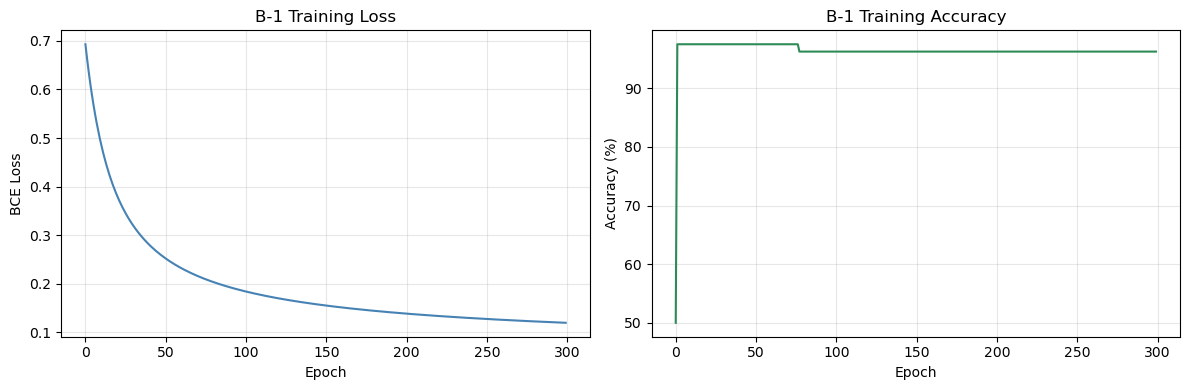

In [ ]:
# B-1. 로지스틱 회귀 학습 루프
np.random.seed(42)
N = 80

age_m  = np.random.randn(N//2) * 8 + 55
age_b  = np.random.randn(N//2) * 8 + 40
size_m = np.random.randn(N//2) * 0.5 + 3
size_b = np.random.randn(N//2) * 0.5 + 1.5

X_b1 = np.column_stack([np.r_[age_m, age_b], np.r_[size_m, size_b]])
y_b1 = np.array([1]*(N//2) + [0]*(N//2)).reshape(-1, 1)
X_b1_norm = (X_b1 - X_b1.mean(0)) / X_b1.std(0)

def sigmoid(z): return 1 / (1 + np.exp(-z))
def bce_loss(yp, yt):
    eps = 1e-8
    return -np.mean(yt * np.log(yp + eps) + (1-yt) * np.log(1-yp+eps))

w_b1, b_b1 = np.zeros((2, 1)), 0.0
lr_b1 = 0.1
loss_hist, acc_hist = [], []

for epoch in range(300):
    y_pred_b1 = sigmoid(X_b1_norm @ w_b1 + b_b1)         # ← 정답 ①
    loss_b1   = bce_loss(y_pred_b1, y_b1)                 # ← 정답 ②
    loss_hist.append(loss_b1)
    preds = (y_pred_b1 >= 0.5).astype(int)
    acc_hist.append(np.mean(preds == y_b1))
    diff  = y_pred_b1 - y_b1
    dw_b1 = (1 / N) * X_b1_norm.T @ diff                  # ← 정답 ③
    db_b1 = np.mean(diff)                                  # ← 정답 ④
    w_b1  = w_b1 - lr_b1 * dw_b1                          # ← 정답 ⑤
    b_b1  = b_b1 - lr_b1 * db_b1                          # ← 정답 ⑥

print(f'Final Loss: {loss_hist[-1]:.4f}')
print(f'Final Accuracy: {acc_hist[-1]*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_hist, color='steelblue')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('B-1 Training Loss'); axes[0].grid(True, alpha=0.3)
axes[1].plot([a*100 for a in acc_hist], color='seagreen')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('B-1 Training Accuracy'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

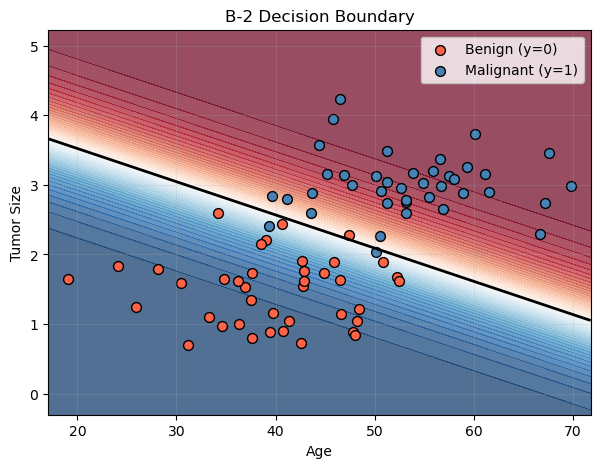

In [ ]:
# B-2. 결정경계 시각화
x1_min, x1_max = X_b1[:, 0].min()-2, X_b1[:, 0].max()+2
x2_min, x2_max = X_b1[:, 1].min()-1, X_b1[:, 1].max()+1

xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                        np.linspace(x2_min, x2_max, 200))

grid = np.c_[xx1.ravel(), xx2.ravel()]
grid_norm = (grid - X_b1.mean(0)) / X_b1.std(0)              # ← 정답 ①
probs_b2  = sigmoid(grid_norm @ w_b1 + b_b1)                  # ← 정답 ②
probs_b2  = probs_b2.reshape(xx1.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx1, xx2, probs_b2, levels=50, cmap='RdBu_r', alpha=0.7, vmin=0, vmax=1)
plt.contour(xx1, xx2, probs_b2, levels=[0.5], colors='black', linewidths=2)  # ← 정답 ③
plt.scatter(X_b1[y_b1.flatten()==0, 0], X_b1[y_b1.flatten()==0, 1],
            color='tomato', label='Benign (y=0)', edgecolors='k', s=50)
plt.scatter(X_b1[y_b1.flatten()==1, 0], X_b1[y_b1.flatten()==1, 1],
            color='steelblue', label='Malignant (y=1)', edgecolors='k', s=50)
plt.xlabel('Age'); plt.ylabel('Tumor Size')
plt.title('B-2 Decision Boundary')
plt.legend(); plt.grid(True, alpha = 0.2)
plt.show()